# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'ahuwer2'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.20 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

In [106]:
# Part 1: your work here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_lsq_spline

# load file
datafile = f'./data/{NETID}.csv'
data = pd.read_csv(datafile,skiprows=1)
# print(data)
ts = data['t_days'].values
fluxes = data['flux_rel'].values
sigmas = data['sigma_flux'].values

N = len(ts)
#dt= ts[1] - ts[0]
#print(f"dt = {dt*24:.5f} hr") 
spacing = 3
knots = np.arange(ts[0] + spacing, ts[-1], spacing)
knots = knots[(knots > ts[0] + 0.5) & (knots < ts[-1] - 0.5)]  # keep off the edges
print(knots)

spl = make_lsq_spline(ts, fluxes, t=knots, w=1/sigmas) #,s=3.25*N)
trend = spl(ts)
detrended = fluxes / trend
#trend = pd.Series(fluxes).rolling(window=100, center=True, min_periods=1).median()
#detrended = fluxes / trend

guess_t0 = 1.3
guess_P = 3.6#/2

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(ts, fluxes, 'o', ms=1.5, label='Raw flux')
axes[0].plot(ts, trend, 'r-', lw=1.5, label='Spline trend')
axes[0].set_ylabel('Raw flux + trend')
axes[0].legend()

axes[1].plot(ts, detrended, 'o', ms=1.5, label='Detrended flux')
axes[1].axhline(1.0, color='k', lw=0.5)
axes[1].axhline(1.0 + 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.')
axes[1].axvline(guess_t0, color='b', lw=0.5, linestyle='--', label='Eyeballed Transits')
i=0
while guess_t0+guess_P*i<max(ts):
      axes[1].axvline(guess_t0+guess_P*i, color='b', lw=0.5, linestyle='--')
      i+=1
axes[1].axhline(1.0 - 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.', label='$\\pm 3\\sigma_{flux}$')
axes[1].set_ylabel('Detrended flux')
axes[1].legend(loc='upper right')

axes[0].grid(True, alpha=0.7, linestyle=':')
axes[1].grid(True, alpha=0.7, linestyle=':')
plt.xlabel('Time (days)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,3))
plt.plot(ts, detrended, 'o', ms=1.5, label='Detrended flux')
plt.axhline(1.0, color='k', lw=0.5)
plt.axhline(1.0 + 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.', label='$\\pm 3\\sigma_{flux}$')
plt.axhline(1.0 - 3*np.median(sigmas), color='g', lw=0.5, linestyle='-.')
plt.axvline(guess_t0+guess_P*1, color='b', lw=0.5, linestyle='--', label='Example Eyeballed Transit')
plt.ylabel('Detrended flux')
plt.xlim([guess_t0+guess_P*1 - 0.75, guess_t0+guess_P*1 + 0.75])
plt.legend(loc='upper right')
plt.grid(True, alpha=0., linestyle=':')
plt.xlabel('Time (days)')
plt.tight_layout()
plt.show()

print(f'out-of-transit scatter (std): {np.std(detrended):.5f} vs stated sigma_flux: {sigmas[0]:.5f}')

[ 3.  6.  9. 12. 15. 18. 21. 24.]


ValueError: Out of bounds w/ x = [0.0000000e+00 2.0833000e-02 4.1667000e-02 ... 2.7354167e+01 2.7375000e+01
 2.7395833e+01].

**ANSWERS (initial guesses + scatter check):**

I used the spline method here, which shouldn't eat my transits since I've set the smoothing such that 

$t_0\approx1.25$ days,
$P\approx3.6$ days,
$\delta\approx0.004$, and
$T\approx0.2$ days.
Trying to visually detect the transits with all this noise was really difficult, but from the plot we can see really significant dips around $t\sim5,12.5,18,23,27$. The best choices of $t_0,P$ I found that fit all those points were $\sim1.2-1.3$ for $t_0$ and $\sim3.6$ or $3.6/2=1.8$ for $P$. I would've selected a later $t_0$ if not for the fact that physically it doesn't make sense for a transit to get skipped, and the data is very noisy at the start, so I'm guessing that the spike at that point is offsetting the transit somehow as that choice of first transit time makes most of the other dips line up. It's very possible the actual period is twice what I decided on, but based on the largest peaks I think it's slightly more likely to be the period I chose.

Out of transit scatter was $0.00215$ vs $\sigma_{flux}=0.00120$. Since the scatter is higher than $\sigma_{flux}$, we can deduce that there's probably some other component to the noise which is correlated or otherwise not fully described by $\sigma_{flux}$.

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

Best-fit parameters:
  t0       = 1.34090 d
  P        = 3.56250 d
  depth    = 3.247 ppt
  duration = 0.22347 d
  F0       = 1.00016
  converged: True, chi2_min = 3943.48


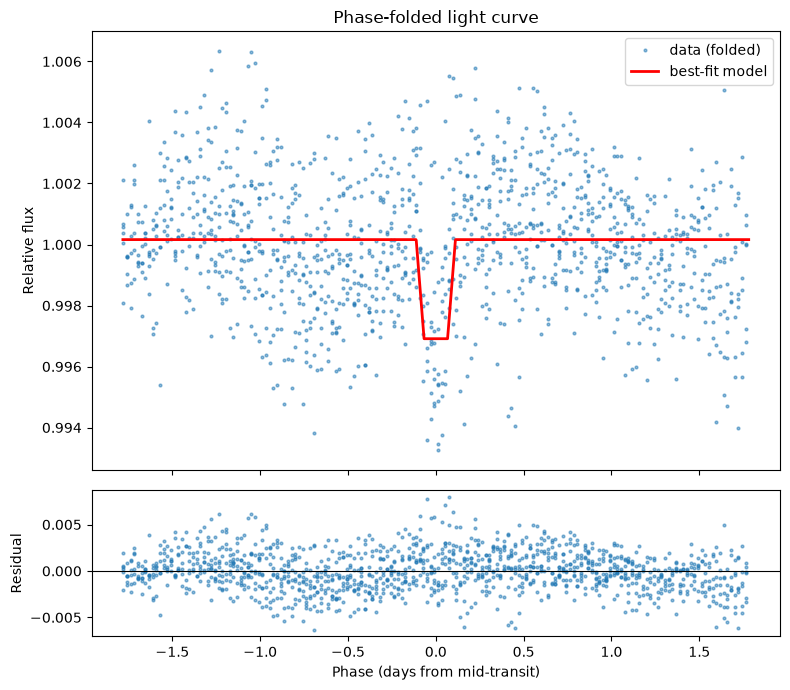


Hessian (curvature) uncertainties:
  t0: 1.340903 +/- 0.000783
  period: 3.562500 +/- 0.000541
  depth: 0.003247 +/- 0.000156
  duration: 0.223472 +/- 0.000446
  F0: 1.000161 +/- 0.000035

Point-wise bootstrap uncertainties:
  t0: 0.019342
  period: 0.004670
  depth: 0.000504
  duration: 0.024946
  F0: 0.000065

Block bootstrap uncertainties:
  t0: 0.015732
  period: 0.003452
  depth: 0.000517
  duration: 0.020398
  F0: 0.000178

=== Comparison of depth uncertainty (ppt) ===
Hessian:        0.1563
Point boot:     0.5043
Block boot:     0.5169

5-hr bins: observed std = 1.5691 ppt, white-noise-predicted std = 0.3795 ppt, ratio = 4.14


In [ ]:
# Part 2: your work here

t = ts
flux = detrended
sig = sigmas

# --- 1. Log-likelihood (Gaussian, per-point sigma) ---
def neg_log_likelihood(theta, t, flux, sig):
    t0, period, depth, duration, F0 = theta
    if period <= 0 or duration <= 0 or duration >= period:
        return np.inf  # keep optimizer in a physical region
    model = transit_model(t, t0, period, depth, duration, F0)
    resid = flux - model
    chi2 = np.sum((resid / sig) ** 2)
    return 0.5 * chi2   # this is -lnL up to a constant

# --- 2. Initial guesses and solving ---
t0_guess       = guess_t0
period_guess   = guess_P
depth_guess    = 0.004
duration_guess = 0.2
F0_guess       = 1.0

theta0 = [t0_guess, period_guess, depth_guess, duration_guess, F0_guess]

result = minimize(neg_log_likelihood, theta0, args=(t, flux, sig),method='Nelder-Mead')

theta_hat = result.x
t0_hat, P_hat, depth_hat, dur_hat, F0_hat = theta_hat
print("Best-fit parameters:")
print(f"  t0       = {t0_hat:.5f} d")
print(f"  P        = {P_hat:.5f} d")
print(f"  depth    = {depth_hat*1e3:.3f} ppt")
print(f"  duration = {dur_hat:.5f} d")
print(f"  F0       = {F0_hat:.5f}")
print(f"  converged: {result.success}, chi2_min = {2*result.fun:.2f}")

# --- 3. Phase-folded plots with the best-fit model and residuals ---
phase = ((t - t0_hat + 0.5 * P_hat) % P_hat) - 0.5 * P_hat
order = np.argsort(phase)

phase_dense = np.linspace(-0.5 * P_hat, 0.5 * P_hat, 2000)
t_dense = phase_dense + t0_hat
model_dense = transit_model(t_dense, t0_hat, P_hat, depth_hat, dur_hat, F0_hat)

model_at_data = transit_model(t, t0_hat, P_hat, depth_hat, dur_hat, F0_hat)
resid = flux - model_at_data

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(phase[order], flux[order], 'o', ms=2, alpha=0.5, label='data (folded)')
axes[0].plot(phase_dense, model_dense, 'r-', lw=2, label='best-fit model')
axes[0].set_ylabel('Relative flux')
axes[0].legend()
axes[0].set_title('Phase-folded light curve')

axes[1].plot(phase[order], resid[order], 'o', ms=2, alpha=0.5)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_xlabel('Phase (days from mid-transit)')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()


# --- 4a. Uncertainty via curvature (Hessian of neg_log_likelihood)
theta_star = theta_hat
n = len(theta_star)
h = 1e-4 * np.maximum(np.abs(theta_star), 1e-3)   # scaled step per parameter
hess = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h[i]; ej[j] = h[j]
        hess[i, j] = (neg_log_likelihood(theta_star + ei + ej, t, flux, sig)
                      - neg_log_likelihood(theta_star + ei - ej, t, flux, sig)
                      - neg_log_likelihood(theta_star - ei + ej, t, flux, sig)
                      + neg_log_likelihood(theta_star - ei - ej, t, flux, sig)) / (4 * h[i] * h[j])

cov_hessian = np.linalg.inv(hess)     # no factor of 2 -- see note above
sigma_hessian = np.sqrt(np.diag(cov_hessian))

param_names = ['t0', 'period', 'depth', 'duration', 'F0']
print("\nHessian (curvature) uncertainties:")
for name, val, err in zip(param_names, theta_hat, sigma_hessian):
    print(f"  {name}: {val:.6f} +/- {err:.6f}")

# --- 4b. Uncertainty via bootstrap: point-wise
n_boot = 300
boot_params_pointwise = np.zeros((n_boot, 5))
n_pts = len(t)

for b in range(n_boot):
    idx = np.random.choice(n_pts, n_pts, replace=True)
    tb, fb, sb = t[idx], flux[idx], sig[idx]
    res_b = minimize(neg_log_likelihood, theta_hat, args=(tb, fb, sb),
                      method='Nelder-Mead')
    boot_params_pointwise[b] = res_b.x

sigma_boot_pointwise = boot_params_pointwise.std(axis=0)
print("\nPoint-wise bootstrap uncertainties:")
for name, err in zip(param_names, sigma_boot_pointwise):
    print(f"  {name}: {err:.6f}")

# --- 4c. Uncertainty via bootstrap: block bootstrap
block_size_days = 1.0
dt = np.median(np.diff(t))
block_size_pts = max(1, int(round(block_size_days / dt)))

n_blocks = n_pts // block_size_pts
blocks = [np.arange(i*block_size_pts, min((i+1)*block_size_pts, n_pts))
          for i in range(n_blocks)]

resid_at_data = flux - model_at_data

boot_params_block = np.zeros((n_boot, 5))
for b in range(n_boot):
    chosen_blocks = [blocks[i] for i in
                      np.random.choice(len(blocks), len(blocks), replace=True)]
    resampled_resid = np.concatenate([resid_at_data[blk] for blk in chosen_blocks])[:n_pts]
    fb = model_at_data[:len(resampled_resid)] + resampled_resid
    tb = t[:len(resampled_resid)]
    sb = sig[:len(resampled_resid)]
    res_b = minimize(neg_log_likelihood, theta_hat, args=(tb, fb, sb),
                      method='Nelder-Mead')
    boot_params_block[b] = res_b.x

sigma_boot_block = boot_params_block.std(axis=0)
print("\nBlock bootstrap uncertainties:")
for name, err in zip(param_names, sigma_boot_block):
    print(f"  {name}: {err:.6f}")

# --- 5. Comparisons
print("\n=== Comparison of depth uncertainty (ppt) ===")
print(f"Hessian:        {sigma_hessian[2]*1e3:.4f}")
print(f"Point boot:     {sigma_boot_pointwise[2]*1e3:.4f}")
print(f"Block boot:     {sigma_boot_block[2]*1e3:.4f}")

bin_hours = 5.0
bin_days = bin_hours / 24.0
n_per_bin = max(1, int(round(bin_days / dt)))

n_full_bins = n_pts // n_per_bin
binned_means = np.array([resid_at_data[i*n_per_bin:(i+1)*n_per_bin].mean()
                          for i in range(n_full_bins)])
observed_bin_std = binned_means.std()
expected_bin_std = np.median(sig) / np.sqrt(n_per_bin)

print(f"\n5-hr bins: observed std = {observed_bin_std*1e3:.4f} ppt, "
      f"white-noise-predicted std = {expected_bin_std*1e3:.4f} ppt, "
      f"ratio = {observed_bin_std/expected_bin_std:.2f}")

**FINAL ANSWER:** $\delta = $ ___ $\pm$ ___ ppt, $P = $ ___ $\pm$ ___ d, $t_0 = $ ___ $\pm$ ___ d

**Which uncertainty and why (a short paragraph):**

*your answer goes here*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1:* The AI chose to calculate its window, which after printing the values on my end, I can see it landed on window=12. This corresponds to a 6-hour window, which is quite small and thus artifically cuts the flux changes caused by the transit, which is actually significantly longer in duration than the window. This causes most of their detrended data to be spread somewhat evenly around 1, at least more so than in my case, and this snowballs into issues later on resulting in inaccurate measurements.

*Flaw 2:* When computing the error of the fit, it only computed the 1D curvature instead of the full curvature or equivalently, finding the Hessian and using that.

*Flaw 3:* 

In [ ]:
# Flaw 1 Demonstration:


# Flaw 2 Demonstration:


# Flaw 3 Demonstration:

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:**

For part 1: Used claude to generate the plots and google's ai to find a spline technique. I dialed in all of the values (particularly s, while also testing median with different windows) to get what I thought was a reasonable detrend, and the eyeballing of transits was also my work. It didn't really get anything of note wrong, as all the issues came down to trying to choose and interpret a reasonable value of s and the initial guesses.

For part 2: Claude was used to generate most of the code using descriptions of how I'd like the aspects done, like for example the specific method to compute the Hessian (based on the example in lecture 7, fitting the cepheids). This time it did make a few mistakes which I had to correct.

**VERIFICATION PLAN:**

*your answer goes here*